In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir("/content/drive/MyDrive")

['Colab Notebooks',
 'Untitled document (4).gdoc',
 'Darshan Resume.pdf',
 '_QUIETSOS ENDORSEMENT BY THE HEAD OF DEPARTMENT .pdf',
 'Untitled document (3).gdoc',
 '_QUIETSOS ENDORSEMENT BY THE HEAD OF DEPARTMENT  (1).gdoc',
 'ENDORSEMENT_BY_THE_HEAD_OF_DEPARTMENT_REGISTRAR_HEAD_OF_INSTITUTION.pdf',
 'UNDERTAKING_FROM_THE_PROJECT_GUIDE.pdf',
 'UNDERTAKING_FROM_THE_PROJECT_GUIDE (2).gdoc',
 'UNDERTAKING_FROM_THE_PROJECT_GUIDE (1).gdoc',
 'UNDERTAKING_FROM_THE_PROJECT_GUIDE.gdoc',
 '_QUIETSOS ENDORSEMENT BY THE HEAD OF DEPARTMENT .gdoc',
 'Untitled document (2).gdoc',
 'DarsanP.gdoc',
 'Untitled document (1).gdoc',
 'DarsanP (1).pdf',
 'DarsanP.pdf',
 'Untitled document.gdoc',
 'Jaw–cheek Muscle Signal Wearable (jc-msw) – Design & Working Document (1).gdoc',
 'Jaw–cheek Muscle Signal Wearable (jc-msw) – Design & Working Document.gdoc',
 'DarsanP_Resume_2026 (3).pdf',
 'DarsanP_Resume_2026 (2).pdf',
 'DarsanP_Resume_2026 (1).pdf',
 'DarsanP_Resume_2026.pdf',
 '10073355.zip',
 'archive.zip'

In [ ]:
!unzip "/content/drive/MyDrive/archive.zip" -d /content/water_dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/water_dataset/Water Bodies Dataset/Images/water_body_1808.jpg  
  inflating: /content/water_dataset/Water Bodies Dataset/Images/water_body_1809.jpg  
  inflating: /content/water_dataset/Water Bodies Dataset/Images/water_body_1810.jpg  
  inflating: /content/water_dataset/Water Bodies Dataset/Images/water_body_1811.jpg  
  inflating: /content/water_dataset/Water Bodies Dataset/Images/water_body_1812.jpg  
  inflating: /content/water_dataset/Water Bodies Dataset/Images/water_body_1813.jpg  
  inflating: /content/water_dataset/Water Bodies Dataset/Images/water_body_1814.jpg  
  inflating: /content/water_dataset/Water Bodies Dataset/Images/water_body_1815.jpg  
  inflating: /content/water_dataset/Water Bodies Dataset/Images/water_body_1816.jpg  
  inflating: /content/water_dataset/Water Bodies Dataset/Images/water_body_1817.jpg  
  inflating: /content/water_dataset/Water Bodies Dataset/Images/water_body_1818.jpg  
  i

In [ ]:
import os
os.listdir("/content/water_dataset")

['Water Bodies Dataset']

In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset

class WaterDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.resize(image, (256,256))
        image = image / 255.0
        image = torch.tensor(image).permute(2,0,1).float()

        mask = cv2.imread(mask_path,0)
        mask = cv2.resize(mask,(256,256))
        mask = mask / 255.0
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [ ]:
image_dir = "/content/water_dataset/Water Bodies Dataset/Images"
mask_dir = "/content/water_dataset/Water Bodies Dataset/Masks"

dataset = WaterDataset(image_dir, mask_dir)

print("Total images:", len(dataset))

Total images: 2841


In [ ]:
img, mask = dataset[0]

print(img.shape)
print(mask.shape)

torch.Size([3, 256, 256])
torch.Size([1, 256, 256])


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

print("DataLoader ready")

DataLoader ready


In [ ]:
for images, masks in train_loader:
    print(images.shape)
    print(masks.shape)
    break

torch.Size([8, 3, 256, 256])
torch.Size([8, 1, 256, 256])


In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.5 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp
import torch

model = smp.Unet(
    encoder_name="resnet34",     # backbone
    encoder_weights="imagenet",  # pretrained weights
    in_channels=3,               # RGB images
    classes=1                    # binary segmentation (water / not water)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Model ready on:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model ready on: cuda


In [ ]:
import torch.optim as optim

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Loss and optimizer ready")

Loss and optimizer ready


In [ ]:
print(model)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
from torch.utils.data import random_split

dataset_size = len(dataset)

train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 2272
Validation size: 569


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 284
Validation batches: 72


In [ ]:
epochs = 25

for epoch in range(epochs):

    # TRAIN
    model.train()
    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch [1/25] Train Loss: 0.2044 | Val Loss: 0.1857
Epoch [2/25] Train Loss: 0.1823 | Val Loss: 0.1800
Epoch [3/25] Train Loss: 0.1643 | Val Loss: 0.1787
Epoch [4/25] Train Loss: 0.1619 | Val Loss: 0.1681
Epoch [5/25] Train Loss: 0.1548 | Val Loss: 0.1781
Epoch [6/25] Train Loss: 0.1462 | Val Loss: 0.2000
Epoch [7/25] Train Loss: 0.1452 | Val Loss: 0.1805
Epoch [8/25] Train Loss: 0.1340 | Val Loss: 0.1784
Epoch [9/25] Train Loss: 0.1233 | Val Loss: 0.1628
Epoch [10/25] Train Loss: 0.1252 | Val Loss: 0.1912
Epoch [11/25] Train Loss: 0.1281 | Val Loss: 0.1751
Epoch [12/25] Train Loss: 0.1162 | Val Loss: 0.1725
Epoch [13/25] Train Loss: 0.1061 | Val Loss: 0.1759
Epoch [14/25] Train Loss: 0.1016 | Val Loss: 0.1723
Epoch [15/25] Train Loss: 0.0991 | Val Loss: 0.1756
Epoch [16/25] Train Loss: 0.0988 | Val Loss: 0.1825
Epoch [17/25] Train Loss: 0.1330 | Val Loss: 0.2300
Epoch [18/25] Train Loss: 0.1406 | Val Loss: 0.1853
Epoch [19/25] Train Loss: 0.1083 | Val Loss: 0.1834
Epoch [20/25] Train L

In [ ]:
import random

sample = random.randint(0, len(val_dataset)-1)

image, mask = val_dataset[sample]

In [ ]:
model.eval()

with torch.no_grad():
    pred = model(image.unsqueeze(0).to(device))
    pred = torch.sigmoid(pred)
    pred = pred.squeeze().cpu().numpy()

In [ ]:
pred_mask = (pred > 0.5).astype("uint8")

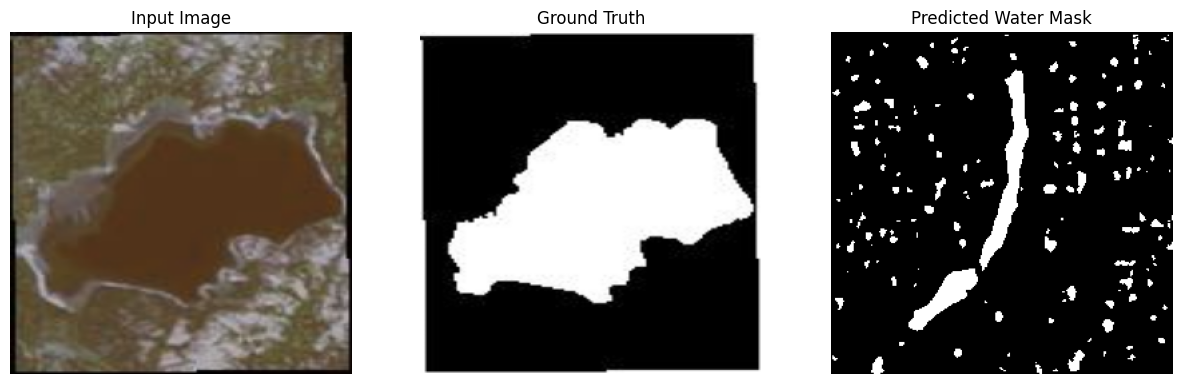

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(image.permute(1,2,0))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Water Mask")
plt.imshow(pred_mask, cmap="gray")
plt.axis("off")

plt.show()

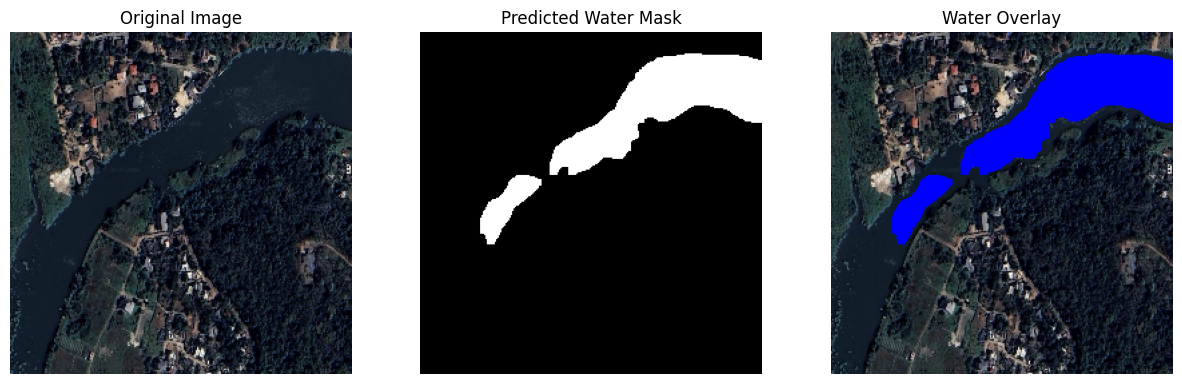

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1. Load Image
# ---------------------------
img = cv2.imread("/content/test5.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize to model input
img_resized = cv2.resize(img, (256,256))
img_norm = img_resized / 255.0

# Convert to tensor
tensor = torch.tensor(img_norm).permute(2,0,1).float().unsqueeze(0).to(device)

# ---------------------------
# 2. Model Prediction
# ---------------------------
model.eval()

with torch.no_grad():
    pred = model(tensor)
    pred = torch.sigmoid(pred)
    pred = pred.squeeze().cpu().numpy()

# ---------------------------
# 3. Binary Mask
# ---------------------------
pred_mask = (pred > 0.8).astype(np.uint8)

# ---------------------------
# 4. Remove Small Noise
# ---------------------------
kernel = np.ones((5,5), np.uint8)

pred_mask = cv2.morphologyEx(pred_mask, cv2.MORPH_OPEN, kernel)
pred_mask = cv2.morphologyEx(pred_mask, cv2.MORPH_CLOSE, kernel)

# ---------------------------
# 5. Keep Only Large Regions
# ---------------------------
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(pred_mask)

clean_mask = np.zeros_like(pred_mask)

for i in range(1, num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area > 500:   # remove tiny detections
        clean_mask[labels == i] = 1

pred_mask = clean_mask

# ---------------------------
# 6. Create Overlay
# ---------------------------
overlay = img_resized.copy()

overlay[pred_mask == 1] = [0,0,255]  # highlight water

# ---------------------------
# 7. Display Results
# ---------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img_resized)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Predicted Water Mask")
plt.imshow(pred_mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Water Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()

In [ ]:
from google.colab import files
files.download("water_unet_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>